# CodSoft ML Internship — Task 4: Spam SMS Detection

**Task:** Build a model that classifies SMS messages as spam or legitimate, using TF-IDF with Naive Bayes, Logistic Regression, or Support Vector Machines.

**Dataset:** [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) (Kaggle/UCI) — 5,574 SMS messages labeled `ham` or `spam`.

> Place `spam.csv` inside a `data/` folder next to this notebook before running. The file is typically Latin-1 encoded with extra unnamed columns, both handled below.


## 1. Imports

In [1]:
import re
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import nltk
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english"))

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Data

In [2]:
df = pd.read_csv("data/spam.csv", encoding="latin-1")
df = df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "message"})
print("Shape:", df.shape)
df.head()

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Label Distribution

label
ham     4825
spam     747
Name: count, dtype: int64
Spam rate: 13.41%


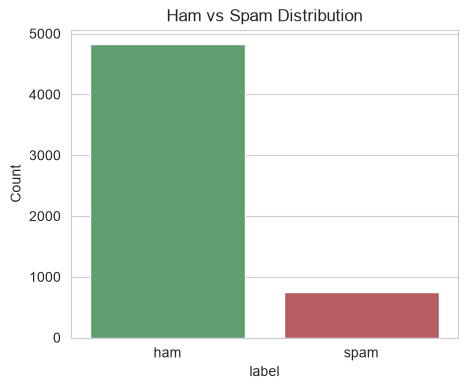

In [3]:
label_counts = df["label"].value_counts()
print(label_counts)
print(f"Spam rate: {label_counts['spam'] / len(df) * 100:.2f}%")

plt.figure(figsize=(5, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index,
            palette=["#55A868", "#C44E52"], legend=False)
plt.ylabel("Count")
plt.title("Ham vs Spam Distribution")
plt.show()

## 4. Clean Text

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df["clean_message"] = df["message"].apply(clean_text)
df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis great world...
1,Ok lar... Joking wif u oni...,lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win cup final tkts may te...
3,U dun say so early hor... U c already then say...,dun say early hor already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


## 5. Train/Test Split + TF-IDF Vectorization

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["clean_message"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print("TF-IDF matrix shape (train):", X_train.shape)

TF-IDF matrix shape (train): (4457, 5000)


## 6. Train Models

In [6]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
}

fitted_models = {}
f1_scores = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    fitted_models[name] = model
    preds = model.predict(X_test)
    f1_scores[name] = f1_score(y_test, preds, pos_label="spam")

Training Naive Bayes...
Training Logistic Regression...
Training Linear SVM...


## 7. Evaluate

In [7]:
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=["ham", "spam"]))
    print(f"F1 (spam class): {f1_scores[name]:.4f}")
    print("-" * 60)

=== Naive Bayes ===
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115

F1 (spam class): 0.8593
------------------------------------------------------------
=== Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       966
        spam       0.88      0.92      0.90       149

    accuracy                           0.97      1115
   macro avg       0.93      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115

F1 (spam class): 0.8984
------------------------------------------------------------
=== Linear SVM ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966


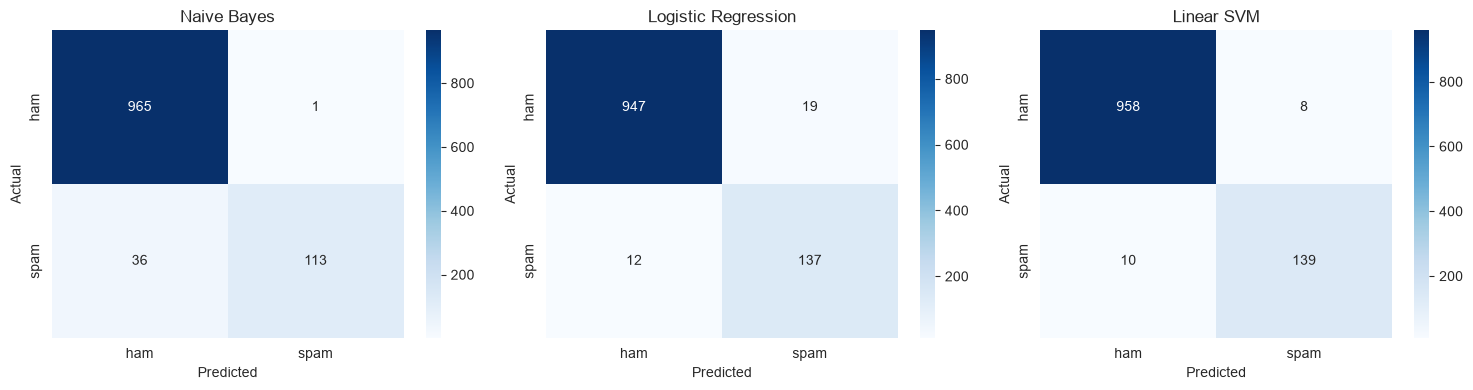

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test), labels=["ham", "spam"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Best Model

In [9]:
best_name = max(f1_scores, key=f1_scores.get)
print("F1 scores:", f1_scores)
print(f"\nBest model: {best_name} (F1 = {f1_scores[best_name]:.4f})")

F1 scores: {'Naive Bayes': 0.8593155893536122, 'Logistic Regression': 0.898360655737705, 'Linear SVM': 0.9391891891891891}

Best model: Linear SVM (F1 = 0.9392)


## 9. Try It Yourself

In [10]:
def predict_message(text, model=fitted_models[best_name], vec=vectorizer):
    cleaned = clean_text(text)
    vec_input = vec.transform([cleaned])
    return model.predict(vec_input)[0]

print(predict_message("Congratulations! You've won a free ticket, call now to claim your prize!"))
print(predict_message("Hey, are we still on for lunch tomorrow?"))

spam
ham


## Conclusion

Naive Bayes, Logistic Regression, and Linear SVM were trained on TF-IDF features from cleaned SMS text to classify messages as spam or ham. Models were compared using precision, recall, and F1 on the spam class, since spam is the minority class in this dataset.
